In [1]:
from sklearn.preprocessing import Normalizer

feature_order = [
    # 'epoch', 'train_size',

    # old
    # 'loss_start', 'loss_mid',
    'loss_last_1', 'loss_last_2',
    # 'loss_growth', 'loss_stability',

    # gap
    # 'gap_last', 'gap_growth', 'gap_std',

    # global
    # 'best_loss',
    'epochs_since_best',
    'global_slope', 'global_curvature',
    # 'distance_from_best',

    # recent
    'recent_slope', 'recent_improvement',

    'acc_norm', 'distance_norm'
]

In [2]:
import pandas as pd
import numpy as np
import ast

from keras.src.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none', 'noise'])]
# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x) // 2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2] / x[0])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3] / x[0])
df['acc_norm'] = df["val_loss"].apply(
    lambda c: ((c[-2] - c[-3]) - (c[-3] - c[-4])) / (c[-3] + 1e-8)
)
df["epoch"] = df["val_loss"].apply(len)
df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

df['distance_norm'] = df['val_loss'].apply(lambda x: (x[-2] - min(x[:-1])) / (x[0] - min(x[:-1]) + 1e-8))


# -------- GLOBAL CONTEXT FEATURES --------

def build_global_features(val_loss):
    val = np.array(val_loss)
    n = len(val)

    x = np.arange(n)

    # --- глобальный тренд ---
    slope = np.polyfit(x, val, 1)[0] if n > 1 else 0

    # --- кривизна (ускорение тренда) ---
    curvature = np.polyfit(x, val, 2)[0] if n > 2 else 0

    # --- лучший момент ---
    best_idx = np.argmin(val)
    best_loss = val[best_idx]

    # --- текущая позиция ---
    current_loss = val[-1]

    return pd.Series({
        "global_slope": slope,
        "global_curvature": curvature,

        "best_loss": best_loss,
        "distance_from_best": current_loss - best_loss,
        "epochs_since_best": n - best_idx,
    })


global_df = df["val_loss"].apply(build_global_features)
df = pd.concat([df, global_df], axis=1)


# -------- LOCAL (RECENT) FEATURES --------

def build_recent_features(val_loss, window=5):
    val = np.array(val_loss)
    n = len(val)

    if n < 2:
        return pd.Series({
            "recent_slope": 0,
            "recent_improvement": 0
        })

    val_recent = val[-window:] if n >= window else val
    x = np.arange(len(val_recent))

    slope = np.polyfit(x, val_recent, 1)[0] if len(val_recent) > 1 else 0

    improvement = val_recent[0] - val_recent[-1]

    return pd.Series({
        "recent_slope": slope,
        "recent_improvement": improvement
    })


recent_df = df["val_loss"].apply(build_recent_features)
df = pd.concat([df, recent_df], axis=1)

# -------- CLEAN --------
train_delta = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
threshold = 0.5 * np.std(train_delta)
df['imbalance'] = df['imbalance'].astype(int)

# df = df.drop(columns=[
#     "val_loss",
#     "train_loss",
#     "val_acc",
#     "index",
#     "seed"
# ])

# -------- FEATURES --------

X = df[feature_order]
y = df["val_loss"].apply(lambda x: (x[-1] - x[-2]) / (x[-2] + 1e-8))
# y = y / np.std(y)
print(df.describe())
print(y.describe())
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

             index        epoch     test_acc  overfitting   train_size  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean   2098.242424    34.793290     0.753080     0.500000  1264.285714   
std    1202.835262    23.561086     0.156870     0.500068  1652.649140   
min       0.000000     6.000000     0.097500     0.000000    50.000000   
25%     993.250000    21.000000     0.639775     0.000000   100.000000   
50%    2211.500000    28.000000     0.769250     0.500000   500.000000   
75%    3135.250000    40.000000     0.889625     1.000000  2000.000000   
max    4059.000000   210.000000     0.982500     1.000000  5000.000000   

              seed    imbalance   loss_start     loss_mid  loss_last_1  ...  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000  ...   
mean      6.106061     0.500000     1.600830     0.721397     0.430032  ...   
std       3.810903     0.500068     0.706650     0.507957     0.176769  ...   
min       0.00000

In [3]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )
model = XGBRegressor()

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.019165702207436738
RMSE: 0.041345589388898596
R2: 0.30769462946235426


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())
# --- модель ---
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # количество признаков
    normalizer,
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu'),

    layers.Dense(1),
])

# --- компиляция ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

# --- обучение ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- предсказание ---
pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8802 - mae: 0.7432 - val_loss: 0.0600 - val_mae: 0.1782
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4498 - mae: 0.5109 - val_loss: 0.0707 - val_mae: 0.1953
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3084 - mae: 0.4163 - val_loss: 0.0637 - val_mae: 0.1691
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2661 - mae: 0.3813 - val_loss: 0.0620 - val_mae: 0.1618
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2310 - mae: 0.3586 - val_loss: 0.0593 - val_mae: 0.1557
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2201 - mae: 0.3484 - val_loss: 0.0564 - val_mae: 0.1534
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1895 - mae: 0.3186 - val_loss: 0.0620 - val_mae: 0.1550
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1786 - mae: 0.3138 - val_loss: 0.0606 - val_mae: 0.1505
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.15

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def benchmark_regressors(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        # обучение
        model.fit(X_train, y_train)

        # предсказание
        pred = model.predict(X_test)

        # метрики
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "mm": model
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("R2", ascending=False)

In [6]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

models = {

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),

    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(),

    "MLP": MLPRegressor(max_iter=500)
}

results = benchmark_regressors(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results)

model_reg = results.iloc[0]["mm"]

                   model        R2       MAE      RMSE  \
3           RandomForest  0.559327  0.016813  0.032987   
4             ExtraTrees  0.521672  0.017290  0.034367   
6   HistGradientBoosting  0.514117  0.018173  0.034637   
5       GradientBoosting  0.489236  0.019203  0.035513   
0       LinearRegression  0.382776  0.020006  0.039039   
1                  Ridge  0.299096  0.022280  0.041602   
10                   MLP  0.275737  0.027411  0.042289   
8                    KNN  0.234841  0.021686  0.043467   
2           DecisionTree  0.117711  0.024604  0.046675   
9                    SVR -0.006370  0.025348  0.049849   
7               AdaBoost -0.038238  0.039726  0.050632   

                                                   mm  
3   (DecisionTreeRegressor(max_features=1.0, rando...  
4   (ExtraTreeRegressor(random_state=751507431), E...  
6                     HistGradientBoostingRegressor()  
5   ([DecisionTreeRegressor(criterion='friedman_ms...  
0                      

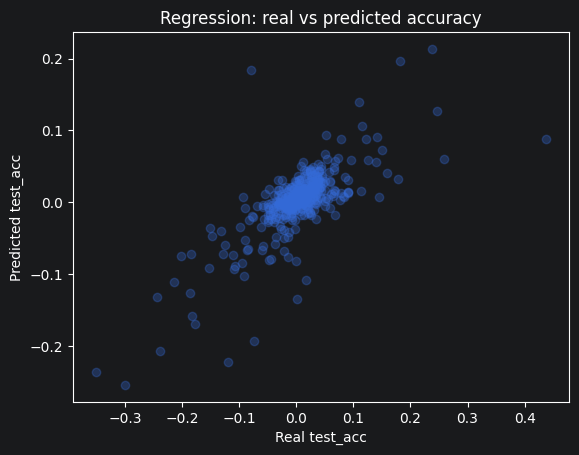

In [7]:
import matplotlib.pyplot as plt

pred = results.iloc[0]["mm"].predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

# plt.plot([0,1],[0,1])
plt.show()


=== Результат предсказания следующего val_loss ===
MAE   = 0.01681
RMSE  = 0.03299
R²    = 0.5593   (55.93%)


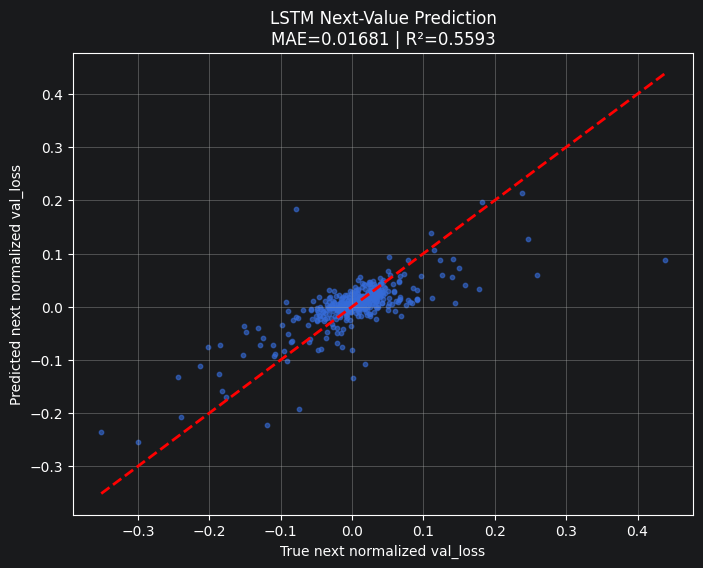

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ========================
# Создаём и обучаем модель
# ========================
# ========================
# Метрики
# ========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2  = r2_score(y_test, pred)

print("\n=== Результат предсказания следующего val_loss ===")
print(f"MAE   = {mae:.5f}")
print(f"RMSE  = {rmse:.5f}")
print(f"R²    = {r2:.4f}   ({r2*100:.2f}%)")

# ========================
# График True vs Predicted
# ========================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True next normalized val_loss")
plt.ylabel("Predicted next normalized val_loss")
plt.title(f"LSTM Next-Value Prediction\nMAE={mae:.5f} | R²={r2:.4f}")
plt.grid(True)
plt.show()

In [9]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback

import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback

class SmartEarlyStoppingMultiStep(Callback):
    def __init__(self,
                 model_meta,
                 train_size,
                 future_steps=5,      # увеличил до 4
                 min_epochs=8,
                 patience=1,
                 restore_best_weights=True):   # ← Новый параметр
        super().__init__()
        self.model_meta = model_meta
        self.train_size = train_size
        self.future_steps = future_steps
        self.min_epochs = min_epochs
        self.patience = patience
        self.restore_best_weights = restore_best_weights

        self.val_loss = []
        self.best_val_loss = np.inf
        self.best_weights = None
        self.best_epoch = 0
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return

        self.val_loss.append(val_loss)

        # === Сохраняем лучшие веса ===
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_weights = self.model.get_weights()   # сохраняем веса
            self.best_epoch = epoch

        if len(self.val_loss) < self.min_epochs:
            return

        # Получаем прогноз
        preds = self.predict_future(epoch)

        current = self.val_loss[-1]
        future_min = min(preds)
        expected_improvement = current - future_min

        recent_std = np.std(self.val_loss[-8:]) if len(self.val_loss) >= 8 else 0.1

        # Более стабильное правило
        if expected_improvement < recent_std * 0.18:
            self.counter += 1
        else:
            self.counter = max(self.counter - 1, 0)

        print(f"epoch={epoch:3d} | val_loss={val_loss:.5f} | "
              f"future={[round(x,4) for x in preds]} | "
              f"improv={expected_improvement:.4f} | std={recent_std:.4f} | "
              f"counter={self.counter} | best={self.best_val_loss:.5f} (ep {self.best_epoch})")

        if self.counter >= self.patience:
            print(f"\n🔴 Expected future increase → stopping at epoch {epoch}")
            print(f"   Best val_loss = {self.best_val_loss:.5f} was at epoch {self.best_epoch}\n")

            # <<< ВОТ ГЛАВНОЕ ИСПРАВЛЕНИЕ >>>
            if self.restore_best_weights and self.best_weights is not None:
                print("→ Restoring best weights from epoch", self.best_epoch)
                self.model.set_weights(self.best_weights)

            self.model.stop_training = True

    def predict_future(self, epoch):
        val = list(self.val_loss)
        preds = []

        for step in range(self.future_steps):
            val_np = np.array(val)
            n = len(val_np)
            if n < 5:
                val_np = np.pad(val_np, (5 - n, 0), 'edge')

            x_full = np.arange(len(val_np))
            global_slope = np.polyfit(x_full, val_np, 1)[0] if len(val_np) > 1 else 0
            global_curvature = np.polyfit(x_full, val_np, 2)[0] if len(val_np) > 2 else 0
            best_idx = np.argmin(val_np)

            recent_window = 5
            val_recent = val_np[-recent_window:] if len(val_np) >= recent_window else val_np
            recent_slope = np.polyfit(np.arange(len(val_recent)), val_recent, 1)[0] if len(val_recent) > 1 else 0

            row = {
                "train_size": self.train_size,
                "epoch": epoch + step,
                "loss_start": val_np[0],
                "loss_mid": val_np[len(val_np)//2],
                "loss_last_1": val_np[-1] / val_np[0],
                "loss_last_2": val_np[-2] / val_np[0] if len(val_np) > 1 else 1.0,
                "global_slope": global_slope,
                "global_curvature": global_curvature,
                "epochs_since_best": len(val_np) - best_idx,
                "recent_slope": recent_slope,
                "recent_improvement": val_recent[0] - val_recent[-1] if len(val_recent) > 1 else 0,
                "acc_norm": (val_np[-1] - 2*val_np[-2] + val_np[-3]) / val_np[0] if len(val_np) > 2 else 0,
                "distance_norm": (val_np[-1] - min(val_np)) / (val_np[0] - min(val_np) + 1e-8),
            }

            df_row = pd.DataFrame([row])[feature_order]
            pred_delta = self.model_meta.predict(df_row)[0]
            next_val = val[-1] * (1 + pred_delta)
            preds.append(next_val)
            val.append(next_val)

        return preds

In [21]:
from tensorflow.keras.callbacks import Callback
import numpy as np
from scipy.optimize import curve_fit


class ParametricEarlyStopping(Callback):
    def __init__(self, min_epochs=8, patience=1, tol=1e-3):
        super().__init__()
        self.min_epochs = min_epochs
        self.patience = patience
        self.tol = tol

        self.val_loss = []
        self.counter = 0

    def exp_func(self, t, a, b, c):
        return a * np.exp(-b * t) + c

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return

        self.val_loss.append(val_loss)

        if len(self.val_loss) < self.min_epochs:
            return

        y = np.array(self.val_loss)
        x = np.arange(len(y))

        try:
            # --- фит ---
            popt, _ = curve_fit(
                self.exp_func,
                x,
                y,
                bounds=(0, [10, 10, 10]),
                maxfev=5000
            )

            a, b, c = popt

            # --- прогноз ---
            future_epochs = np.arange(len(y), len(y) + 5)
            preds = self.exp_func(future_epochs, a, b, c)

            current = y[-1]
            future_min = preds.min()
            expected_improvement = current - future_min

            print(f"[Parametric] epoch={epoch} "
                  f"improv={expected_improvement:.6f} "
                  f"a={a:.3f} b={b:.3f} c={c:.3f}")

            if expected_improvement < self.tol:
                self.counter += 1
            else:
                self.counter = max(self.counter - 1, 0)

            if self.counter >= self.patience:
                print(f"🔵 Parametric stop at epoch {epoch}")
                self.model.stop_training = True

        except Exception:
            # если фит не сошёлся — игнорим
            pass

In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)


def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(32, activation="relu"),  # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")  # выходной слой
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
smart_stop = SmartEarlyStoppingMultiStep(
    model_reg,
    2000
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mnist.fit(
    X_train[:2000],
    y_train[:2000],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    # callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]

    callbacks=[smart_stop], verbose=0,
)



D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.26606 | future=[np.float64(0.2707), np.float64(0.271), np.float64(0.2697), np.float64(0.271), np.float64(0.2713)] | improv=-0.0037 | std=0.1204 | counter=1 | best=0.26363 (ep 6)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.26363 was at epoch 6

→ Restoring best weights from epoch 6


In [12]:
from tensorflow.keras.callbacks import EarlyStopping


def run_training(X, y, train_size, callback, X_test_df, y_test_df, build_model):
    curr_model = build_model()
    history = curr_model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = curr_model.evaluate(X_test_df, y_test_df, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [23]:
def runner(sizes, X_train_df, y_train_Df, X_test_df, y_test_df, build_model):
    runs = 4

    results = []
    count = len(sizes) * runs
    for j, size in enumerate(sizes):

        for r in range(runs):
            print(j * runs + r, count, "*" * 20)
            early = EarlyStopping(
                monitor="val_loss",
                patience=5
            )
            parametric = ParametricEarlyStopping()
            smart = SmartEarlyStoppingMultiStep(
                model_reg,
                size
            )

            res_early = run_training(X_train_df, y_train_Df, size, early, X_test_df, y_test_df, build_model)
            res_smart = run_training(X_train_df, y_train_Df, size, smart, X_test_df, y_test_df, build_model)
            res_param = run_training(X_train_df, y_train_Df, size, parametric, X_test_df, y_test_df, build_model)
            results.append({
                "train_size": size,
                "run": r,

                "early_epochs": res_early["epochs"],
                "early_acc": res_early["test_acc"],
                "early_loss": res_early["test_loss"],

                "smart_epochs": res_smart["epochs"],
                "smart_acc": res_smart["test_acc"],
                "smart_loss": res_smart["test_loss"],
                "param_epochs": res_param["epochs"],
                "param_acc": res_param["test_acc"],
                "param_loss": res_param["test_loss"],
            })

    dfl = pd.DataFrame(results)
    dfl['diff_epochs'] = dfl['early_epochs'] - dfl['smart_epochs']
    dfl['diff_loss'] = dfl['early_loss'] - dfl['smart_loss']
    dfl['diff_acc'] = dfl['early_acc'] - dfl['smart_acc']
    return dfl


In [ ]:
def sum_df(df_curr, sizes, k=-0.002):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df_curr = df_curr.copy()

    # =========================
    # 🔹 FEATURE ENGINEERING
    # =========================

    df_curr["rel_epochs_saved"] = df_curr["diff_epochs"] / (df_curr["early_epochs"] + 1e-8)
    df_curr["acc_per_epoch"] = df_curr["diff_acc"] / (df_curr["diff_epochs"] + 1e-8)

    # Utility (ключевая метрика)
    df_curr["utility"] = df_curr["diff_acc"] + k * df_curr["diff_epochs"]

    # Победа Smart
    df_curr["smart_better"] = df_curr["utility"] > 0

    # Parametric diff
    df_curr["param_diff_epochs"] = df_curr["early_epochs"] - df_curr["param_epochs"]
    df_curr["param_diff_acc"] = df_curr["early_acc"] - df_curr["param_acc"]

    # =========================
    # 🔹 SUMMARY
    # =========================

    summary = df_curr.groupby("train_size").agg({
        "param_epochs": "mean",
        "param_acc": "mean",
        "param_loss": "mean",

        "early_acc": "mean",
        "smart_acc": "mean",

        "early_loss": "mean",
        "smart_loss": "mean",

        "early_epochs": "mean",
        "smart_epochs": "mean",

        "diff_epochs": "mean",
        "diff_acc": "mean",
        "diff_loss": "mean",

        "rel_epochs_saved": "mean",
        "utility": "mean",
        "smart_better": "mean"
    })

    print(summary)

    # =========================
    # 🔹 LOSS COMPARISON
    # =========================

    plt.figure(figsize=(8, 5))
    plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
    plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")
    plt.plot(summary.index, summary["param_loss"], marker="o", label="ParamStop")

    plt.xlabel("train_size")
    plt.ylabel("test_loss")
    plt.title("Callback quality comparison")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 🔹 EPOCHS BARPLOT
    # =========================

    summary[["early_epochs", "smart_epochs", "param_epochs"]].plot(
        kind="bar", figsize=(8, 5)
    )
    plt.ylabel("epochs trained")
    plt.title("Epochs until stopping")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 TRADE-OFF (SMART)
    # =========================

    plt.figure(figsize=(8, 5))

    for size in sizes:
        subset = df_curr[df_curr["train_size"] == size]

        plt.scatter(
            subset["diff_epochs"],
            subset["diff_acc"],
            c=subset["utility"],
            cmap="coolwarm",
            s=80,
            alpha=0.8,
            label=f"{size}"
        )

    # Decision boundary
    x_vals = np.linspace(df_curr["diff_epochs"].min(), df_curr["diff_epochs"].max(), 100)
    y_vals = -k * x_vals
    plt.plot(x_vals, y_vals, linestyle="--", color="black", label=f"boundary k={k}")

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff (early - smart)")
    plt.title("Trade-off: speed vs accuracy (Smart)")
    plt.legend(title="train_size")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 SMART vs PARAMETRIC
    # =========================

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_curr["param_diff_epochs"],
        df_curr["param_diff_acc"],
        alpha=0.6,
        label="Parametric"
    )

    plt.scatter(
        df_curr["diff_epochs"],
        df_curr["diff_acc"],
        alpha=0.6,
        label="Smart"
    )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff")
    plt.title("Smart vs Parametric trade-off")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 🔹 UTILITY DISTRIBUTION
    # =========================

    plt.figure(figsize=(8, 5))

    for size in sizes:
        subset = df_curr[df_curr["train_size"] == size]
        plt.scatter([size] * len(subset), subset["utility"])

    plt.axhline(0, linestyle="--")
    plt.xlabel("train_size")
    plt.ylabel("utility")
    plt.title("Utility vs dataset size")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 WIN RATE
    # =========================

    plt.figure(figsize=(8, 5))

    plt.plot(summary.index, summary["smart_better"], marker="o")

    plt.xlabel("train_size")
    plt.ylabel("P(Smart better)")
    plt.title("Win rate of SmartEarlyStopping")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 PARETO FRONTIER
    # =========================

    df_sorted = df_curr.sort_values("diff_epochs")

    pareto = []
    best_acc = -np.inf

    for _, row in df_sorted.iterrows():
        if row["diff_acc"] > best_acc:
            pareto.append(row)
            best_acc = row["diff_acc"]

    pareto = pd.DataFrame(pareto)

    plt.figure(figsize=(8, 5))

    plt.scatter(df_curr["diff_epochs"], df_curr["diff_acc"], alpha=0.4)
    plt.plot(pareto["diff_epochs"], pareto["diff_acc"], color="black", linewidth=2)

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff")
    plt.title("Pareto frontier")
    plt.grid()
    plt.show()

    return summary, df_curr
sizes = [50, 500, 1000, 2000, 5000]

In [34]:
df = runner(sizes, X_train, y_train, X_test, y_test, build_mlp_overfit)

0 20 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [1]:
sum_df(df, sizes)
print(df.head(100))

NameError: name 'sum_df' is not defined

In [39]:
from pandas import read_csv, get_dummies
from sklearn.model_selection import train_test_split

df_student_med = read_csv('data/WineQT.csv')

X, Y = df_student_med[
    'fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol'.split(
        ',')
], df_student_med['quality']
X = get_dummies(X, drop_first=True)
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X = normalizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# print(y_test[:90])
def build_model_med():
    model = models.Sequential([
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


df_med = runner(sizes, X_train, y_train, X_test, y_test, build_model_med)

0 20 ********************
epoch=  7 | val_loss=1.88296 | future=[np.float64(1.8425), np.float64(1.8083), np.float64(1.774), np.float64(1.7385), np.float64(1.7045)] | improv=0.1785 | std=0.1297 | counter=0 | best=1.88296 (ep 7)
epoch=  8 | val_loss=1.82906 | future=[np.float64(1.7892), np.float64(1.755), np.float64(1.721), np.float64(1.6867), np.float64(1.6533)] | improv=0.1758 | std=0.1284 | counter=0 | best=1.82906 (ep 8)
epoch=  9 | val_loss=1.77363 | future=[np.float64(1.7364), np.float64(1.7052), np.float64(1.672), np.float64(1.6391), np.float64(1.6068)] | improv=0.1668 | std=0.1273 | counter=0 | best=1.77363 (ep 9)
epoch= 10 | val_loss=1.71941 | future=[np.float64(1.6827), np.float64(1.6524), np.float64(1.6202), np.float64(1.5883), np.float64(1.5582)] | improv=0.1612 | std=0.1264 | counter=0 | best=1.71941 (ep 10)
epoch= 11 | val_loss=1.66452 | future=[np.float64(1.6287), np.float64(1.5987), np.float64(1.5673), np.float64(1.537), np.float64(1.5081)] | improv=0.1565 | std=0.1260 | 

            param_epochs  param_acc  param_loss  early_acc  smart_acc  \
train_size                                                              
50                110.25   0.472707    1.147078   0.427948   0.456332   
500                 8.25   0.531659    1.112205   0.548035   0.497817   
1000                8.00   0.494541    1.095736   0.484716   0.482533   
2000                8.00   0.482533    1.096679   0.518559   0.493450   
5000                8.00   0.479258    1.096744   0.510917   0.537118   

            early_loss  smart_loss  early_epochs  smart_epochs  diff_epochs  \
train_size                                                                    
50            1.163800    1.156185         52.00         43.75         8.25   
500           1.078224    1.115456         27.00          9.25        17.75   
1000          1.074220    1.097762         23.25          8.50        14.75   
2000          1.060960    1.095264         31.50          9.00        22.50   
5000          

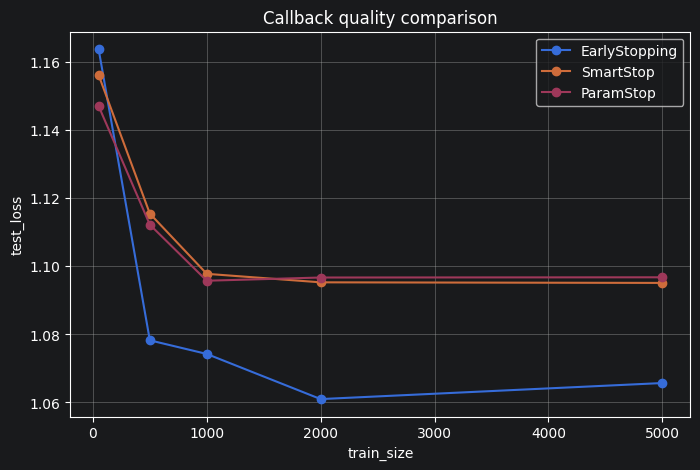

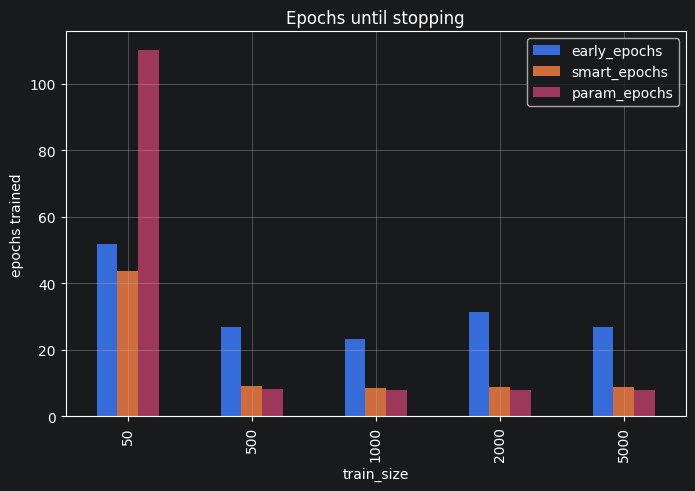

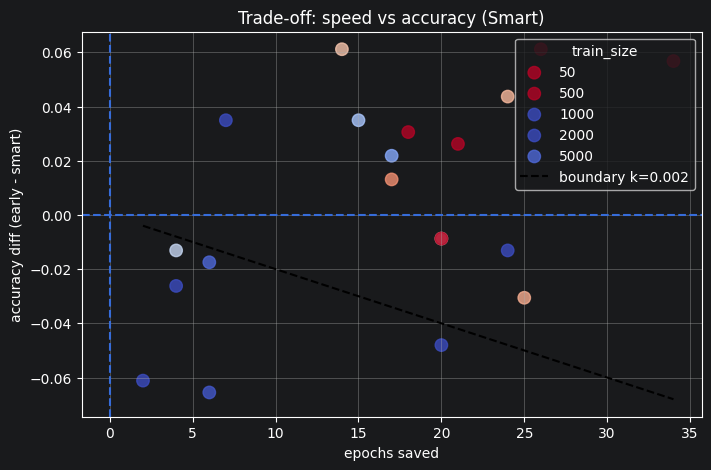

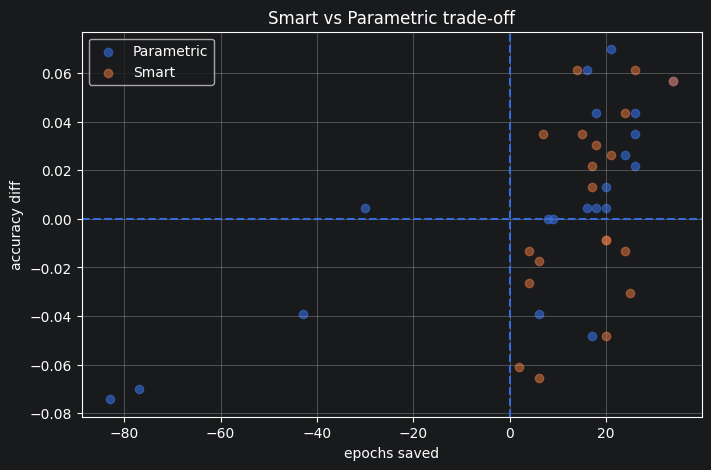

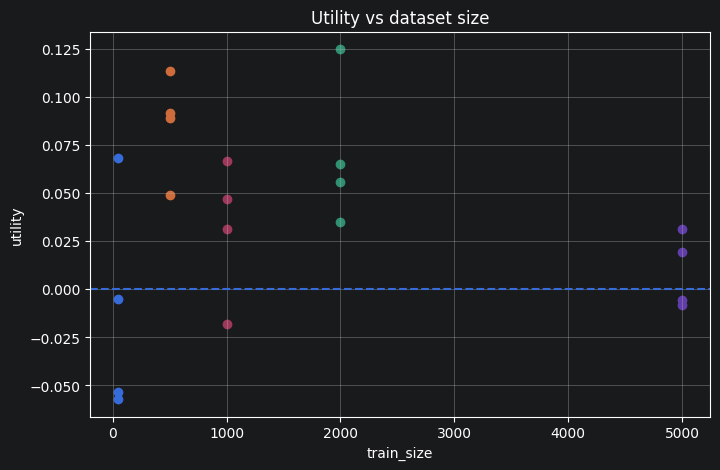

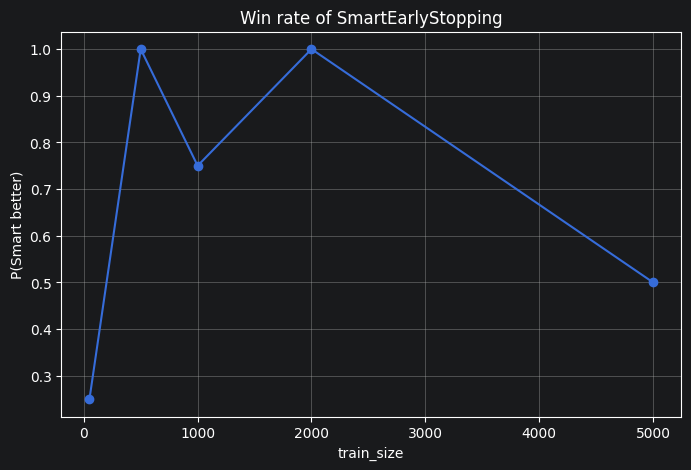

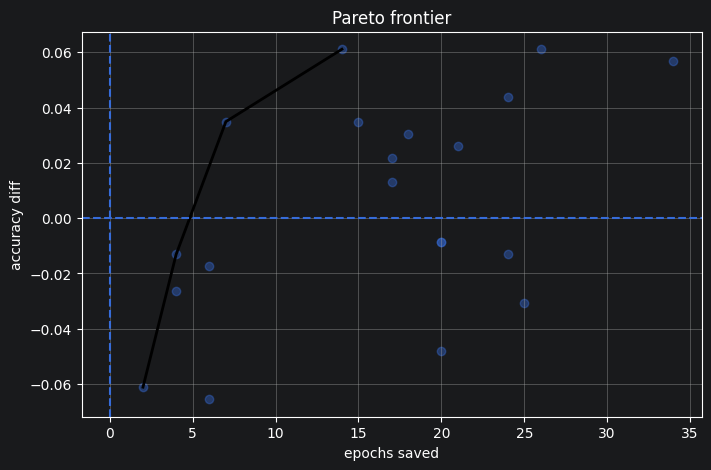

    train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0           50    0            60   0.462882    1.158069            39   
1           50    1            52   0.419214    1.165417            46   
2           50    2            49   0.427948    1.169348            45   
3           50    3            47   0.401747    1.162365            45   
4          500    0            34   0.550218    1.076145             8   
5          500    1            24   0.550218    1.078108            10   
6          500    2            17   0.537118    1.086365            10   
7          500    3            33   0.554585    1.072279             9   
8         1000    0            14   0.458515    1.086457            10   
9         1000    1            26   0.515284    1.066426             8   
10        1000    2            28   0.475983    1.069857             8   
11        1000    3            25   0.489083    1.074140             8   
12        2000    0            34   0.

In [40]:
sum_df(df_med, sizes)
print(df_med.head(100))


In [42]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# ====================== ЗАГРУЗКА CIFAR-10 ======================
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Нормализация данных (приведение к диапазону [0, 1])
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Преобразование меток в одномерный массив (для sparse_categorical_crossentropy)
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print(f"Полный размер обучающей выборки: {X_train_full.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ====================== ФУНКЦИЯ СОЗДАНИЯ МОДЕЛИ ======================
def build_model_cifar():
    model = models.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.1),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ====================== ЗАПУСК ЭКСПЕРИМЕНТА ======================
# Размеры обучающей выборки, которые будем тестировать

# Запуск сравнения EarlyStopping vs SmartEarlyStopping
df_cifar = runner(sizes, X_train_full, y_train_full, X_test, y_test, build_model_cifar)

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


MemoryError: Unable to allocate 586. MiB for an array with shape (50000, 32, 32, 3) and data type float32

In [ ]:
print(df_cifar.head(100))
sum_df(df_cifar, sizes)
